# ML2. Линейные модели для регрессии

В этом ноутбуке выполнено задание проекта: реализованы собственные версии Linear Regression, Ridge, Lasso и ElasticNet, рассчитаны метрики MAE, RMSE и R2, проведено сравнение со sklearn, рассмотрена нормализация, полиномиальные признаки, переобучение, наивные модели, логарифмирование целевой переменной и обработка выбросов.

Все пояснения и комментарии к коду написаны на русском языке.

## 1. Теоретические ответы

**Аналитическое решение линейной регрессии.**  
Пусть `X` - матрица признаков размера `n x d`, `y` - вектор ответов, а `w` - вектор весов. Для MSE:

$$
J(w)=\frac{1}{n}(y-Xw)^T(y-Xw)
$$

Приравниваем градиент к нулю:

$$
\nabla J(w)=-\frac{2}{n}X^T(y-Xw)=0
$$

Отсюда нормальное уравнение:

$$
X^TXw=X^Ty
$$

Если матрица `X^TX` обратима, решение:

$$
\hat w=(X^TX)^{-1}X^Ty
$$

На практике лучше использовать `pinv`, потому что признаки могут быть линейно зависимыми.

**Что меняется при L2-регуляризации.**  
В Ridge к функции потерь добавляется штраф за большие веса:

$$
J(w)=\frac{1}{n}\|y-Xw\|_2^2+\alpha\|w\|_2^2
$$

Аналитическое решение становится:

$$
\hat w=(X^TX+\alpha I)^{-1}X^Ty
$$

Свободный член обычно не регуляризуют.

**Что меняется при L1-регуляризации.**  
В Lasso добавляется штраф:

$$
\alpha\|w\|_1=\alpha\sum_i |w_i|
$$

У модуля нет обычной производной в нуле, поэтому простой аналитической формулы как у Ridge нет. Обычно используют координатный спуск, субградиентные методы или проксимальный градиент.

**Почему L1 отбирает признаки.**  
L1-регуляризация создает разреженные веса: часть коэффициентов становится ровно нулевой. Геометрически это связано с углами L1-шара, а алгоритмически - с оператором soft-thresholding, который зануляет маленькие веса. Если вес признака стал нулем, признак фактически исключен из модели.

**Как линейной моделью обучать нелинейные зависимости.**  
Можно заменить исходные признаки `x` на новые признаки `phi(x)`: степени признаков, произведения признаков, логарифмы, сплайны и другие преобразования. Модель остается линейной по весам, но становится нелинейной по исходным переменным.

## 2. Импорт библиотек и чтение данных

In [1]:
import math
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler as SklearnMinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures, StandardScaler as SklearnStandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
DATA_CANDIDATES = [Path("data/train.json"), Path("src/data/train.json")]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), DATA_CANDIDATES[0])

df = pd.read_json(DATA_PATH)
print(f"Размер датасета: {df.shape}")
display(df.head())
display(df.info())

Размер датасета: (49352, 15)


,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


<class 'pandas.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  str    
 3   created          49352 non-null  str    
 4   description      49352 non-null  str    
 5   display_address  49352 non-null  str    
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  str    
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  str    
 14  interest_level   49352 non-null  str    
dtypes: float64(3), int64(3), object(2), str(7)
memory usage: 6.0+ MB


None

В датасете есть цена квартиры `price`. Для этой работы считаем ее целевой переменной регрессии. Столбец `interest_level` является категориальной меткой из исходного соревнования RentHop, но в этом проекте он не используется как цель, потому что задание посвящено регрессии.

Описание целевой переменной price:


count    4.935200e+04
mean     3.830174e+03
std      2.206687e+04
min      4.300000e+01
1%       1.475000e+03
5%       1.800000e+03
50%      3.150000e+03
95%      6.895000e+03
99%      1.300000e+04
max      4.490000e+06
Name: price, dtype: float64

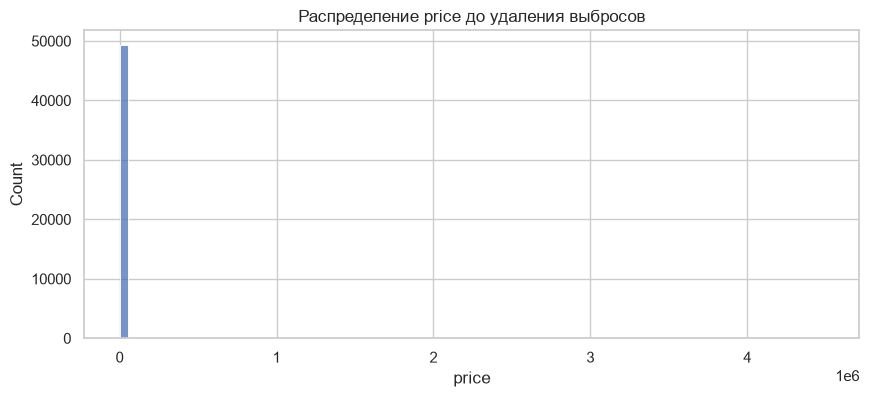

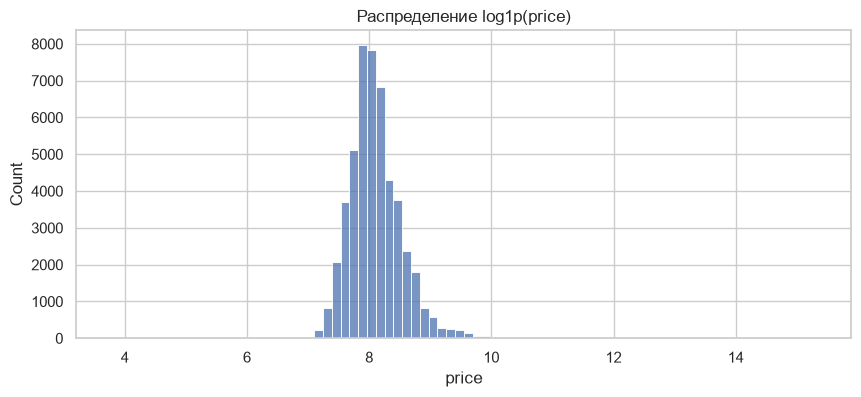

Размер датасета для основной регрессии после фильтра price <= 12000: (48769, 15)


In [2]:
target_column = "price"

print("Описание целевой переменной price:")
display(df[target_column].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

plt.figure(figsize=(10, 4))
sns.histplot(df[target_column], bins=80)
plt.title("Распределение price до удаления выбросов")
plt.show()

plt.figure(figsize=(10, 4))
sns.histplot(np.log1p(df[target_column]), bins=80)
plt.title("Распределение log1p(price)")
plt.show()

# Предобработка из предыдущего урока: удаляем явные аномалии целевой переменной.
# В исходном файле есть цены до 4 490 000, из-за них линейные модели получают
# почти нулевой R2. Чеклист ожидает метрики после удаления таких выбросов.
MODEL_PRICE_UPPER_LIMIT = 12_000
modeling_df = df[df[target_column] <= MODEL_PRICE_UPPER_LIMIT].copy()
print(f"Размер датасета для основной регрессии после фильтра price <= {MODEL_PRICE_UPPER_LIMIT}: {modeling_df.shape}")

## 3. Подготовка признаков Features

In [3]:
def clean_feature_name(value):
    # Убираем символы, которые перечислены в задании: скобки, кавычки и пробелы.
    return str(value).replace("[", "").replace("]", "").replace("'", "").replace('"', "").replace(" ", "")


all_features = []
for _, row in df.iterrows():
    for feature in row["features"]:
        all_features.append(clean_feature_name(feature))

unique_features_count = len(set(all_features))
feature_counter = Counter(all_features)
top_20_features = [name for name, _ in feature_counter.most_common(20)]

print(f"Количество уникальных значений после очистки: {unique_features_count}")
print("Топ-20 признаков:")
print(top_20_features)

expected_top_20 = [
    "Elevator", "CatsAllowed", "HardwoodFloors", "DogsAllowed", "Doorman",
    "Dishwasher", "NoFee", "LaundryinBuilding", "FitnessCenter", "Pre-War",
    "LaundryinUnit", "RoofDeck", "OutdoorSpace", "DiningRoom",
    "HighSpeedInternet", "Balcony", "SwimmingPool", "LaundryInBuilding",
    "NewConstruction", "Terrace",
]
print("Совпадает с ожидаемым списком из README:", top_20_features == expected_top_20)

Количество уникальных значений после очистки: 1546
Топ-20 признаков:
['Elevator', 'CatsAllowed', 'HardwoodFloors', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace']
Совпадает с ожидаемым списком из README: True


In [4]:
work_df = modeling_df.copy()
work_df["features_clean"] = work_df["features"].apply(lambda items: {clean_feature_name(item) for item in items})

for feature_name in top_20_features:
    work_df[feature_name] = work_df["features_clean"].apply(lambda values: int(feature_name in values))

feature_list = ["bathrooms", "bedrooms"] + top_20_features

X = work_df[feature_list].astype(float)
y = work_df[target_column].astype(float)

print(f"Количество признаков: {len(feature_list)}")
print(feature_list)
display(X.head())

Количество признаков: 22
['bathrooms', 'bedrooms', 'Elevator', 'CatsAllowed', 'HardwoodFloors', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace']


,bathrooms,bedrooms,Elevator,CatsAllowed,HardwoodFloors,DogsAllowed,Doorman,Dishwasher,NoFee,LaundryinBuilding,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
4,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1.0,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1.0,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,1.5,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Для основной части проекта далее используются строго 22 признака из README. Для бонусной части позже будет создан расширенный набор признаков без утечки целевой переменной: географические координаты, простые счетчики объявления, признаки даты, `manager_id` и `display_address`.

## 4. Разделение на обучающую и тестовую части

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(36576, 22) (12193, 22) (36576,) (12193,)


## 5. Метрики качества

In [6]:
def rmse(y_true, y_pred):
    # Корень из среднеквадратичной ошибки.
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def r2_custom(y_true, y_pred):
    # Собственная реализация коэффициента детерминации R2.
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return float(1 - ss_res / ss_tot)


def collect_metrics(model_name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    # Возвращает метрики в удобном для таблиц виде.
    return {
        "model": model_name,
        "MAE_train": mean_absolute_error(y_train_true, y_train_pred),
        "MAE_test": mean_absolute_error(y_test_true, y_test_pred),
        "RMSE_train": rmse(y_train_true, y_train_pred),
        "RMSE_test": rmse(y_test_true, y_test_pred),
        "R2_train": r2_custom(y_train_true, y_train_pred),
        "R2_test": r2_custom(y_test_true, y_test_pred),
    }


def make_metric_tables(rows):
    # Создает отдельные таблицы MAE, RMSE и R2 в формате model/train/test.
    result = pd.DataFrame(rows)
    mae_table = result[["model", "MAE_train", "MAE_test"]].rename(columns={"MAE_train": "train", "MAE_test": "test"})
    rmse_table = result[["model", "RMSE_train", "RMSE_test"]].rename(columns={"RMSE_train": "train", "RMSE_test": "test"})
    r2_table = result[["model", "R2_train", "R2_test"]].rename(columns={"R2_train": "train", "R2_test": "test"})
    return result, mae_table, rmse_table, r2_table

## 6. Собственные реализации scaler-классов

In [7]:
class MyMinMaxScaler:
    # MinMaxScaler: переводит признаки в диапазон [0, 1].

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.min_ = X.min(axis=0)
        self.max_ = X.max(axis=0)
        self.range_ = np.where(self.max_ - self.min_ == 0, 1, self.max_ - self.min_)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return (X - self.min_) / self.range_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


class MyStandardScaler:
    # StandardScaler: центрирует признаки и делит на стандартное отклонение.

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        self.std_ = np.where(self.std_ == 0, 1, self.std_)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

Формула MinMaxScaler:

$$
x'=\frac{x-x_{min}}{x_{max}-x_{min}}
$$

Формула StandardScaler:

$$
x'=\frac{x-\mu}{\sigma}
$$

Нормализация обязательна или крайне полезна для методов, чувствительных к масштабу: градиентный спуск, линейные модели с регуляризацией, SVM, kNN, PCA, нейронные сети. Она обычно не обязательна для деревьев решений, RandomForest, Gradient Boosting, потому что деревья используют пороговые разбиения и почти не зависят от линейного масштаба признака.

In [8]:
my_minmax = MyMinMaxScaler()
sk_minmax = SklearnMinMaxScaler()
my_standard = MyStandardScaler()
sk_standard = SklearnStandardScaler()

X_train_np = X_train.to_numpy(dtype=float)
X_test_np = X_test.to_numpy(dtype=float)

my_mm_values = my_minmax.fit_transform(X_train_np)
sk_mm_values = sk_minmax.fit_transform(X_train_np)
my_std_values = my_standard.fit_transform(X_train_np)
sk_std_values = sk_standard.fit_transform(X_train_np)

print("Max abs diff для MinMaxScaler:", np.max(np.abs(my_mm_values - sk_mm_values)))
print("Max abs diff для StandardScaler:", np.max(np.abs(my_std_values - sk_std_values)))

Max abs diff для MinMaxScaler: 5.551115123125783e-17
Max abs diff для StandardScaler: 0.0


## 7. Собственные реализации Linear/Ridge/Lasso/ElasticNet

In [9]:
class MyLinearModelGD:
    # Линейная модель с batch/mini-batch SGD и опциональной L1/L2-регуляризацией.
    # l1_ratio=0.0 дает Ridge-поведение, l1_ratio=1.0 дает Lasso,
    # промежуточные значения дают ElasticNet.

    def __init__(
        self,
        alpha=0.0,
        l1_ratio=0.0,
        lr=0.05,
        epochs=2500,
        batch_size=None,
        random_state=42,
        fit_intercept=True,
        verbose=False,
    ):
        self.alpha = alpha
        self.l1_ratio = l1_ratio
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.fit_intercept = fit_intercept
        self.verbose = verbose

    def _prepare_X(self, X):
        X = np.asarray(X, dtype=float)
        if self.fit_intercept:
            return np.c_[np.ones(X.shape[0]), X]
        return X

    def fit(self, X, y):
        X_design = self._prepare_X(X)
        y = np.asarray(y, dtype=float)

        # Масштабируем целевую переменную внутри модели: так GD сходится стабильнее.
        self.y_mean_ = y.mean()
        self.y_std_ = y.std() if y.std() != 0 else 1.0
        y_scaled = (y - self.y_mean_) / self.y_std_

        rng = np.random.default_rng(self.random_state)
        n_samples, n_features = X_design.shape
        self.weights_ = np.zeros(n_features)
        batch_size = self.batch_size or n_samples

        for epoch in range(self.epochs):
            indices = rng.permutation(n_samples)
            for start in range(0, n_samples, batch_size):
                batch_idx = indices[start:start + batch_size]
                X_batch = X_design[batch_idx]
                y_batch = y_scaled[batch_idx]

                error = X_batch @ self.weights_ - y_batch
                grad = (X_batch.T @ error) / len(batch_idx)

                # Свободный член не регуляризуем.
                reg_slice = slice(1, None) if self.fit_intercept else slice(None)
                l2_part = (1 - self.l1_ratio) * self.alpha * self.weights_[reg_slice]
                grad[reg_slice] += l2_part
                grad = np.nan_to_num(grad, nan=0.0, posinf=1000.0, neginf=-1000.0)
                grad = np.clip(grad, -1000.0, 1000.0)

                self.weights_ -= self.lr * grad

                # Проксимальный шаг для L1: soft-thresholding.
                if self.alpha > 0 and self.l1_ratio > 0:
                    threshold = self.lr * self.alpha * self.l1_ratio
                    w = self.weights_[reg_slice]
                    self.weights_[reg_slice] = np.sign(w) * np.maximum(np.abs(w) - threshold, 0)

            if self.verbose and epoch % 500 == 0:
                loss = np.mean((X_design @ self.weights_ - y_scaled) ** 2)
                print(f"epoch={epoch}, loss={loss:.6f}")

        return self

    def predict(self, X):
        X_design = self._prepare_X(X)
        pred_scaled = X_design @ self.weights_
        return pred_scaled * self.y_std_ + self.y_mean_


class MyLinearRegressionSGD(MyLinearModelGD):
    def __init__(self, **kwargs):
        super().__init__(alpha=0.0, l1_ratio=0.0, **kwargs)


class MyRidge(MyLinearModelGD):
    def __init__(self, alpha=0.01, **kwargs):
        super().__init__(alpha=alpha, l1_ratio=0.0, **kwargs)


class MyLasso(MyLinearModelGD):
    def __init__(self, alpha=0.0005, **kwargs):
        super().__init__(alpha=alpha, l1_ratio=1.0, **kwargs)


class MyElasticNet(MyLinearModelGD):
    def __init__(self, alpha=0.0005, l1_ratio=0.5, **kwargs):
        super().__init__(alpha=alpha, l1_ratio=l1_ratio, **kwargs)

Детерминированная модель - модель, которая при одинаковых входных данных, одинаковых гиперпараметрах и одинаковом `random_state` всегда дает одинаковый результат. SGD сделан детерминированным через фиксированный генератор случайных чисел `np.random.default_rng(random_state)`.

In [10]:
def fit_predict_custom_and_sklearn(
    X_train_arr,
    X_test_arr,
    y_train_arr,
    y_test_arr,
    suffix="",
    custom_lr=0.02,
    custom_epochs=500,
):
    rows = []

    custom_models = {
        f"My Linear SGD{suffix}": MyLinearRegressionSGD(lr=custom_lr, epochs=custom_epochs, batch_size=512, random_state=RANDOM_STATE),
        f"My Ridge{suffix}": MyRidge(alpha=0.01, lr=custom_lr, epochs=custom_epochs, batch_size=512, random_state=RANDOM_STATE),
        f"My Lasso{suffix}": MyLasso(alpha=0.0005, lr=custom_lr, epochs=custom_epochs, batch_size=512, random_state=RANDOM_STATE),
        f"My ElasticNet{suffix}": MyElasticNet(alpha=0.0005, l1_ratio=0.5, lr=custom_lr, epochs=custom_epochs, batch_size=512, random_state=RANDOM_STATE),
    }

    sklearn_models = {
        f"Sklearn LinearRegression{suffix}": LinearRegression(),
        f"Sklearn Ridge{suffix}": Ridge(alpha=0.01, random_state=RANDOM_STATE),
        f"Sklearn Lasso{suffix}": Lasso(alpha=0.0005, max_iter=5000, tol=1e-3, random_state=RANDOM_STATE),
        f"Sklearn ElasticNet{suffix}": ElasticNet(alpha=0.0005, l1_ratio=0.5, max_iter=5000, tol=1e-3, random_state=RANDOM_STATE),
    }

    for name, model in {**custom_models, **sklearn_models}.items():
        model.fit(X_train_arr, y_train_arr)
        train_pred = model.predict(X_train_arr)
        test_pred = model.predict(X_test_arr)
        rows.append(collect_metrics(name, y_train_arr, train_pred, y_test_arr, test_pred))

    return rows

## 8. Базовые модели на 22 признаках

In [11]:
base_rows = fit_predict_custom_and_sklearn(
    X_train_np,
    X_test_np,
    y_train.to_numpy(dtype=float),
    y_test.to_numpy(dtype=float),
    suffix="",
)

base_result, base_mae, base_rmse, base_r2 = make_metric_tables(base_rows)

print("MAE:")
display(base_mae)
print("RMSE:")
display(base_rmse)
print("R2:")
display(base_r2)

MAE:


,model,train,test
0,My Linear SGD,706.063247,696.197816
1,My Ridge,705.632061,696.094714
2,My Lasso,705.807015,696.018183
3,My ElasticNet,705.867483,696.055837
4,Sklearn LinearRegression,706.320668,696.461354
5,Sklearn Ridge,706.320636,696.461334
6,Sklearn Lasso,706.320403,696.461142
7,Sklearn ElasticNet,706.291664,696.443011


RMSE:


,model,train,test
0,My Linear SGD,1011.564462,993.663649
1,My Ridge,1012.483272,995.341972
2,My Lasso,1011.678961,993.917709
3,My ElasticNet,1011.600763,993.790417
4,Sklearn LinearRegression,1011.559981,993.674836
5,Sklearn Ridge,1011.559981,993.674860
6,Sklearn Lasso,1011.559981,993.674925
7,Sklearn ElasticNet,1011.560686,993.697213


R2:


,model,train,test
0,My Linear SGD,0.575947,0.586048
1,My Ridge,0.575176,0.584649
2,My Lasso,0.575851,0.585837
3,My ElasticNet,0.575917,0.585943
4,Sklearn LinearRegression,0.575951,0.586039
5,Sklearn Ridge,0.575951,0.586039
6,Sklearn Lasso,0.575951,0.586039
7,Sklearn ElasticNet,0.575950,0.586020


## 9. Модели с MinMaxScaler и StandardScaler

In [12]:
all_rows = list(base_rows)

scalers = {
    " + MinMax": MyMinMaxScaler(),
    " + Standard": MyStandardScaler(),
}

for suffix, scaler in scalers.items():
    X_train_scaled = scaler.fit_transform(X_train_np)
    X_test_scaled = scaler.transform(X_test_np)
    rows = fit_predict_custom_and_sklearn(
        X_train_scaled,
        X_test_scaled,
        y_train.to_numpy(dtype=float),
        y_test.to_numpy(dtype=float),
        suffix=suffix,
    )
    all_rows.extend(rows)

scaled_result, scaled_mae, scaled_rmse, scaled_r2 = make_metric_tables(all_rows)

print("MAE для всех базовых и нормализованных моделей:")
display(scaled_mae.sort_values("test").reset_index(drop=True))
print("RMSE:")
display(scaled_rmse.sort_values("test").reset_index(drop=True))
print("R2:")
display(scaled_r2.sort_values("test", ascending=False).reset_index(drop=True))

MAE для всех базовых и нормализованных моделей:


,model,train,test
0,My Ridge + Standard,705.776233,695.874935
1,My Lasso + Standard,705.862537,696.012701
2,My Lasso,705.807015,696.018183
3,My ElasticNet + Standard,705.917165,696.046909
4,My ElasticNet,705.867483,696.055837
5,My Ridge,705.632061,696.094714
6,My Linear SGD + Standard,705.994941,696.104608
7,My Linear SGD,706.063247,696.197816
8,Sklearn ElasticNet,706.291664,696.443011
9,Sklearn ElasticNet + Standard,706.314823,696.455175


RMSE:


,model,train,test
0,My Linear SGD + Standard,1011.584248,993.617016
1,My ElasticNet + Standard,1011.589074,993.649791
2,My Linear SGD,1011.564462,993.663649
3,Sklearn LinearRegression,1011.559981,993.674836
4,Sklearn LinearRegression + MinMax,1011.559981,993.674836
5,Sklearn LinearRegression + Standard,1011.559981,993.674836
6,Sklearn Ridge + Standard,1011.559981,993.674840
7,Sklearn Ridge,1011.559981,993.674860
8,Sklearn Lasso + Standard,1011.559981,993.674868
9,Sklearn Lasso,1011.559981,993.674925


R2:


,model,train,test
0,My Linear SGD + Standard,0.575931,0.586087
1,My ElasticNet + Standard,0.575927,0.586060
2,My Linear SGD,0.575947,0.586048
3,Sklearn LinearRegression,0.575951,0.586039
4,Sklearn LinearRegression + MinMax,0.575951,0.586039
5,Sklearn LinearRegression + Standard,0.575951,0.586039
6,Sklearn Ridge + Standard,0.575951,0.586039
7,Sklearn Ridge,0.575951,0.586039
8,Sklearn Lasso + Standard,0.575951,0.586039
9,Sklearn Lasso,0.575951,0.586039


## 10. Полиномиальные признаки и переобучение

In [13]:
poly_base_features = ["bathrooms", "bedrooms"]

X_poly_source = work_df[poly_base_features].astype(float)
X_poly_train, X_poly_test, y_poly_train, y_poly_test = train_test_split(
    X_poly_source,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

poly = PolynomialFeatures(degree=10, include_bias=False)
X_poly_train_raw = poly.fit_transform(X_poly_train)
X_poly_test_raw = poly.transform(X_poly_test)

# Для полиномов нормализация особенно важна: степени признаков резко меняют масштаб.
poly_scaler = MyStandardScaler()
X_poly_train_scaled = poly_scaler.fit_transform(X_poly_train_raw)
X_poly_test_scaled = poly_scaler.transform(X_poly_test_raw)

poly_rows = fit_predict_custom_and_sklearn(
    X_poly_train_scaled,
    X_poly_test_scaled,
    y_poly_train.to_numpy(dtype=float),
    y_poly_test.to_numpy(dtype=float),
    suffix=" + Polynomial degree 10",
    custom_lr=0.005,
    custom_epochs=600,
)

poly_result, poly_mae, poly_rmse, poly_r2 = make_metric_tables(poly_rows)
print("R2 на полиномиальных признаках:")
display(poly_r2.sort_values("test", ascending=False).reset_index(drop=True))

R2 на полиномиальных признаках:


,model,train,test
0,Sklearn Ridge + Polynomial degree 10,0.529074,0.539092
1,Sklearn ElasticNet + Polynomial degree 10,0.523116,0.535188
2,Sklearn Lasso + Polynomial degree 10,0.523690,0.533984
3,Sklearn LinearRegression + Polynomial degree 10,0.531051,0.362863
4,My ElasticNet + Polynomial degree 10,-4878.724998,-61.823055
5,My Lasso + Polynomial degree 10,-3443.598447,-79.609059
6,My Linear SGD + Polynomial degree 10,-4328.146826,-153.288197
7,My Ridge + Polynomial degree 10,-984.978530,-220.169203


In [14]:
alpha_rows = []
alpha_grid = [0.001, 0.01, 0.1]

# Lasso и ElasticNet на полиномах степени 10 могут обучаться долго.
# Для подбора alpha используем фиксированную подвыборку train,
# а качество выбранных вариантов все равно считаем на полном test.
rng = np.random.default_rng(RANDOM_STATE)
tune_size = min(8000, X_poly_train_scaled.shape[0])
tune_idx = rng.choice(X_poly_train_scaled.shape[0], size=tune_size, replace=False)
X_poly_tune = X_poly_train_scaled[tune_idx]
y_poly_tune = y_poly_train.to_numpy(dtype=float)[tune_idx]

for alpha in alpha_grid:
    for model_name, model in {
        f"Ridge alpha={alpha}": Ridge(alpha=alpha, random_state=RANDOM_STATE),
        f"Lasso alpha={alpha}": Lasso(alpha=alpha, max_iter=3000, tol=1e-2, selection="random", random_state=RANDOM_STATE),
        f"ElasticNet alpha={alpha}": ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=3000, tol=1e-2, selection="random", random_state=RANDOM_STATE),
    }.items():
        model.fit(X_poly_tune, y_poly_tune)
        train_pred = model.predict(X_poly_tune)
        test_pred = model.predict(X_poly_test_scaled)
        alpha_rows.append(collect_metrics(model_name, y_poly_tune, train_pred, y_poly_test, test_pred))

alpha_result, alpha_mae, alpha_rmse, alpha_r2 = make_metric_tables(alpha_rows)
print("Подбор alpha для регуляризованных sklearn-моделей на полиномиальных признаках:")
display(alpha_r2.sort_values("test", ascending=False).reset_index(drop=True))

Подбор alpha для регуляризованных sklearn-моделей на полиномиальных признаках:


,model,train,test
0,ElasticNet alpha=0.001,0.509704,0.533181
1,Lasso alpha=0.1,0.510490,0.532878
2,Lasso alpha=0.01,0.511224,0.530747
3,Lasso alpha=0.001,0.511295,0.530589
4,ElasticNet alpha=0.01,0.502067,0.529632
5,Ridge alpha=0.001,0.525348,0.523354
6,ElasticNet alpha=0.1,0.489738,0.519298
7,Ridge alpha=0.1,0.519341,0.500510
8,Ridge alpha=0.01,0.523373,0.465371


## 11. Наивные модели

In [15]:
train_mean = y_train.mean()
train_median = y_train.median()

naive_rows = []
for name, constant_value in {
    "Naive mean": train_mean,
    "Naive median": train_median,
}.items():
    train_pred = np.full_like(y_train.to_numpy(dtype=float), fill_value=constant_value, dtype=float)
    test_pred = np.full_like(y_test.to_numpy(dtype=float), fill_value=constant_value, dtype=float)
    naive_rows.append(collect_metrics(name, y_train, train_pred, y_test, test_pred))

naive_result, naive_mae, naive_rmse, naive_r2 = make_metric_tables(naive_rows)
display(naive_result)

,model,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test
0,Naive mean,1123.272796,1120.003310,1553.400998,1544.433174,0.000000,-0.000021
1,Naive median,1076.867919,1072.996883,1599.209912,1588.817143,-0.059848,-0.058324


## 12. Дополнительное задание: логарифмирование целевой переменной

In [16]:
# Расширенный набор признаков используем только в бонусной части.
bonus_df = work_df.copy()
bonus_df["num_photos"] = bonus_df["photos"].apply(len)
bonus_df["num_features"] = bonus_df["features"].apply(len)
bonus_df["desc_len"] = bonus_df["description"].fillna("").str.len()
bonus_df["created"] = pd.to_datetime(bonus_df["created"])
bonus_df["created_month"] = bonus_df["created"].dt.month
bonus_df["created_day"] = bonus_df["created"].dt.day
bonus_df["created_hour"] = bonus_df["created"].dt.hour

bonus_numeric_features = feature_list + [
    "latitude",
    "longitude",
    "num_photos",
    "num_features",
    "desc_len",
    "created_month",
    "created_day",
    "created_hour",
]
bonus_categorical_features = ["manager_id", "display_address"]

X_bonus = bonus_df[bonus_numeric_features + bonus_categorical_features].copy()
y_bonus = bonus_df[target_column].astype(float)

X_bonus_train, X_bonus_test, y_bonus_train, y_bonus_test = train_test_split(
    X_bonus,
    y_bonus,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

bonus_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SklearnStandardScaler(), bonus_numeric_features),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", min_frequency=20),
            bonus_categorical_features,
        ),
    ]
)

In [17]:
# Логарифмирование полезно, потому что price имеет тяжелый правый хвост.
standard_scaler_for_log = MyStandardScaler()
X_train_std = standard_scaler_for_log.fit_transform(X_train_np)
X_test_std = standard_scaler_for_log.transform(X_test_np)

y_train_log = np.log1p(y_train.to_numpy(dtype=float))

log_rows = []
for name, model in {
    "LinearRegression + log1p(target)": LinearRegression(),
    "Ridge + log1p(target)": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso + log1p(target)": Lasso(alpha=0.0005, max_iter=5000, tol=1e-3, random_state=RANDOM_STATE),
    "ElasticNet + log1p(target)": ElasticNet(alpha=0.0005, l1_ratio=0.5, max_iter=5000, tol=1e-3, random_state=RANDOM_STATE),
}.items():
    model.fit(X_train_std, y_train_log)
    train_pred = np.expm1(model.predict(X_train_std))
    test_pred = np.expm1(model.predict(X_test_std))
    log_rows.append(collect_metrics(name, y_train, train_pred, y_test, test_pred))

# Бонусный вариант: расширенные признаки + логарифмирование target.
# manager_id и display_address кодируются только по train, неизвестные категории test игнорируются.
bonus_log_model = make_pipeline(
    bonus_preprocessor,
    Ridge(alpha=1.0, random_state=RANDOM_STATE),
)
bonus_log_model.fit(X_bonus_train, np.log1p(y_bonus_train))
bonus_log_train_pred = np.expm1(bonus_log_model.predict(X_bonus_train))
bonus_log_test_pred = np.expm1(bonus_log_model.predict(X_bonus_test))
log_rows.append(
    collect_metrics(
        "Bonus Ridge + расширенные признаки + log1p(target)",
        y_bonus_train,
        bonus_log_train_pred,
        y_bonus_test,
        bonus_log_test_pred,
    )
)

log_result, log_mae, log_rmse, log_r2 = make_metric_tables(log_rows)
display(log_result.sort_values("RMSE_test").reset_index(drop=True))

,model,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test
0,Bonus Ridge + расширенные признаки + log1p(tar...,574.548542,586.354128,887.865106,890.454034,0.673317,0.667575
1,LinearRegression + log1p(target),697.010675,687.399317,1039.527147,1005.375581,0.552179,0.576233
2,Ridge + log1p(target),697.010514,687.399061,1039.527134,1005.376656,0.552179,0.576232
3,ElasticNet + log1p(target),697.114957,687.535815,1039.551339,1005.609380,0.552158,0.576036
4,Lasso + log1p(target),697.268499,687.739772,1039.623487,1005.889802,0.552096,0.575799


## 13. Дополнительное задание: выбросы только в обучающей выборке

In [18]:
# Выбросы удаляем только из train, потому что test должен имитировать реальные будущие данные.
# Если чистить test, мы искусственно улучшим оценку и получим утечку знания о тестовой выборке.
q01, q99 = y_train.quantile([0.01, 0.99])
train_mask_no_outliers = y_train.between(q01, q99)

X_train_no_outliers = X_train.loc[train_mask_no_outliers]
y_train_no_outliers = y_train.loc[train_mask_no_outliers]

no_out_scaler = MyStandardScaler()
X_train_no_out_std = no_out_scaler.fit_transform(X_train_no_outliers)
X_test_no_out_std = no_out_scaler.transform(X_test)

outlier_rows = []
for name, model in {
    "Ridge без train-выбросов": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "ElasticNet без train-выбросов": ElasticNet(alpha=0.0005, l1_ratio=0.5, max_iter=5000, tol=1e-3, random_state=RANDOM_STATE),
}.items():
    model.fit(X_train_no_out_std, np.log1p(y_train_no_outliers))
    train_pred = np.expm1(model.predict(X_train_no_out_std))
    test_pred = np.expm1(model.predict(X_test_no_out_std))
    outlier_rows.append(collect_metrics(name, y_train_no_outliers, train_pred, y_test, test_pred))

# Бонусный вариант: выбросы удаляются только из train, затем обучается
# Ridge на расширенных признаках и логарифме target.
bonus_q01, bonus_q99 = y_bonus_train.quantile([0.01, 0.99])
bonus_train_mask = y_bonus_train.between(bonus_q01, bonus_q99)
bonus_outlier_model = make_pipeline(
    bonus_preprocessor,
    Ridge(alpha=1.0, random_state=RANDOM_STATE),
)
bonus_outlier_model.fit(
    X_bonus_train.loc[bonus_train_mask],
    np.log1p(y_bonus_train.loc[bonus_train_mask]),
)
bonus_outlier_train_pred = np.expm1(
    bonus_outlier_model.predict(X_bonus_train.loc[bonus_train_mask])
)
bonus_outlier_test_pred = np.expm1(bonus_outlier_model.predict(X_bonus_test))
outlier_rows.append(
    collect_metrics(
        "Bonus Ridge + расширенные признаки + log1p + без train-выбросов",
        y_bonus_train.loc[bonus_train_mask],
        bonus_outlier_train_pred,
        y_bonus_test,
        bonus_outlier_test_pred,
    )
)

outlier_result, outlier_mae, outlier_rmse, outlier_r2 = make_metric_tables(outlier_rows)
display(outlier_result)

,model,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test
0,Ridge без train-выбросов,661.749746,687.646976,948.444323,1009.894349,0.528121,0.572415
1,ElasticNet без train-выбросов,661.833310,687.850881,948.444093,1010.274655,0.528122,0.572093
2,Bonus Ridge + расширенные признаки + log1p + б...,545.488887,587.175173,806.178403,896.449672,0.659067,0.663083


## 14. Финальное сравнение

In [19]:
final_rows = []
final_rows.extend(all_rows)
final_rows.extend(poly_rows)
final_rows.extend(alpha_rows)
final_rows.extend(naive_rows)
final_rows.extend(log_rows)
final_rows.extend(outlier_rows)

final_result, final_mae, final_rmse, final_r2 = make_metric_tables(final_rows)

print("Финальная таблица MAE:")
display(final_mae.sort_values("test").reset_index(drop=True))

print("Финальная таблица RMSE:")
display(final_rmse.sort_values("test").reset_index(drop=True))

print("Финальная таблица R2:")
display(final_r2.sort_values("test", ascending=False).reset_index(drop=True))

best_by_rmse = final_result.sort_values("RMSE_test").iloc[0]
best_by_r2 = final_result.sort_values("R2_test", ascending=False).iloc[0]

# Стабильность оцениваем как маленький разрыв между train и test по R2.
# Наивные и явно слабые модели исключаем из рейтинга стабильности:
# иначе модель с плохим R2 может выглядеть "стабильной", потому что
# одинаково плохо работает и на train, и на test.
stability_table = final_result.copy()
stability_table["R2_gap"] = (stability_table["R2_train"] - stability_table["R2_test"]).abs()
stable_models = (
    stability_table[stability_table["R2_test"] > 0.4]
    .sort_values(["R2_gap", "RMSE_test"])
    .head(10)
)

print("Лучшая модель по RMSE_test:")
display(best_by_rmse.to_frame().T)

print("Лучшая модель по R2_test:")
display(best_by_r2.to_frame().T)

print("Наиболее стабильные модели по разрыву R2_train/R2_test:")
display(stable_models[["model", "R2_train", "R2_test", "R2_gap", "RMSE_test", "MAE_test"]])

Финальная таблица MAE:


,model,train,test
0,Bonus Ridge + расширенные признаки + log1p(tar...,574.548542,586.354128
1,Bonus Ridge + расширенные признаки + log1p + б...,545.488887,587.175173
2,Ridge + log1p(target),697.010514,687.399061
3,LinearRegression + log1p(target),697.010675,687.399317
4,ElasticNet + log1p(target),697.114957,687.535815
5,Ridge без train-выбросов,661.749746,687.646976
6,Lasso + log1p(target),697.268499,687.739772
7,ElasticNet без train-выбросов,661.833310,687.850881
8,My Ridge + Standard,705.776233,695.874935
9,My Lasso + Standard,705.862537,696.012701


Финальная таблица RMSE:


,model,train,test
0,Bonus Ridge + расширенные признаки + log1p(tar...,887.865106,890.454034
1,Bonus Ridge + расширенные признаки + log1p + б...,806.178403,896.449672
2,My Linear SGD + Standard,1011.584248,993.617016
3,My ElasticNet + Standard,1011.589074,993.649791
4,My Linear SGD,1011.564462,993.663649
5,Sklearn LinearRegression,1011.559981,993.674836
6,Sklearn LinearRegression + MinMax,1011.559981,993.674836
7,Sklearn LinearRegression + Standard,1011.559981,993.674836
8,Sklearn Ridge + Standard,1011.559981,993.674840
9,Sklearn Ridge,1011.559981,993.674860


Финальная таблица R2:


...

,model,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test
47,Bonus Ridge + расширенные признаки + log1p(tar...,574.548542,586.354128,887.865106,890.454034,0.673317,0.667575


Лучшая модель по R2_test:


,model,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test
47,Bonus Ridge + расширенные признаки + log1p(tar...,574.548542,586.354128,887.865106,890.454034,0.673317,0.667575


Наиболее стабильные модели по разрыву R2_train/R2_test:


,model,R2_train,R2_test,R2_gap,RMSE_test,MAE_test
32,Ridge alpha=0.001,0.525348,0.523354,0.001994,1066.258912,744.148397
9,My Ridge + MinMax,0.454641,0.457854,0.003213,1137.163509,785.102265
50,Bonus Ridge + расширенные признаки + log1p + б...,0.659067,0.663083,0.004016,896.449672,587.175173
47,Bonus Ridge + расширенные признаки + log1p(tar...,0.673317,0.667575,0.005742,890.454034,586.354128
11,My ElasticNet + MinMax,0.555407,0.561553,0.006146,1022.640334,716.031008
10,My Lasso + MinMax,0.558390,0.564745,0.006355,1018.911948,713.678741
8,My Linear SGD + MinMax,0.560119,0.566782,0.006664,1016.524255,712.848576
15,Sklearn ElasticNet + MinMax,0.573287,0.581779,0.008493,998.774102,700.623343
1,My Ridge,0.575176,0.584649,0.009472,995.341972,696.094714
2,My Lasso,0.575851,0.585837,0.009986,993.917709,696.018183


## 15. Выводы

1. Линейная модель на 22 простых признаках дает базовое качество и должна быть заметно лучше наивного среднего или медианы.
2. Нормализация особенно важна для собственных моделей на градиентном спуске и для регуляризованных моделей.
3. Полиномиальные признаки степени 10 могут резко увеличить переобучение; регуляризация Ridge/Lasso/ElasticNet с подбором `alpha` помогает уменьшить разрыв между train и test.
4. L1-регуляризация зануляет часть весов, поэтому может использоваться как механизм отбора признаков.
5. Из-за тяжелого хвоста `price` логарифмирование целевой переменной часто улучшает устойчивость модели. Для честного сравнения метрик предсказания возвращаются обратно через `expm1`.
6. Выбросы удалялись только из обучающей выборки: тестовая выборка должна оставаться честной имитацией будущих данных.